In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()

# Load the dataset
df = pd.read_excel('Happiness index.xlsx')

# Display the first 5 rows to verify the structure
print(df.head())

       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                   1.32629  1.32261   

   Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
0                   0.94143  0.66557                        0.41978   
1                   0.94784  0.62877                        0.14145   
2                   0.87464  0.64938           

In [5]:
from sklearn.preprocessing import StandardScaler

# Define the features (independent variables matching your Orange setup)
features = [
    'Economy (GDP per Capita)',
    'Family',
    'Health (Life Expectancy)',
    'Freedom',
    'Trust (Government Corruption)',
    'Generosity'
]

# Set 'Country' as a meta/label attribute
meta_attribute = df['Country']
X = df[features]

# Standardize features (mean = 0, variance = 1) for fair clustering comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully. Shape of scaled data:", X_scaled.shape)

Features scaled successfully. Shape of scaled data: (158, 6)


In [6]:
# Calculate correlation matrix including Happiness Score
corr_df = df[features + ['Happiness Score']].corr()

# Display correlation with Happiness Score
print("Correlation with Happiness Score:")
print(corr_df['Happiness Score'].sort_values(ascending=False))

Correlation with Happiness Score:
Happiness Score                  1.000000
Economy (GDP per Capita)         0.780966
Family                           0.740605
Health (Life Expectancy)         0.724200
Freedom                          0.568211
Trust (Government Corruption)    0.395199
Generosity                       0.180319
Name: Happiness Score, dtype: float64


In [7]:
from sklearn.cluster import KMeans

# Set up K-Means with 3 clusters (e.g., Developed/High Well-being, Developing, Struggling)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# View average metrics per cluster to understand their socioeconomic profile
cluster_summary = df.groupby('Cluster')[features + ['Happiness Score']].mean()
print(cluster_summary)

         Economy (GDP per Capita)    Family  Health (Life Expectancy)  \
Cluster                                                                 
0                        0.980120  1.056143                  0.732992   
1                        0.369585  0.737940                  0.336673   
2                        1.302792  1.250101                  0.856586   

          Freedom  Trust (Government Corruption)  Generosity  Happiness Score  
Cluster                                                                        
0        0.401858                       0.088927    0.184052         5.576582  
1        0.366064                       0.132607    0.254268         4.206500  
2        0.609351                       0.310519    0.353076         6.844517  


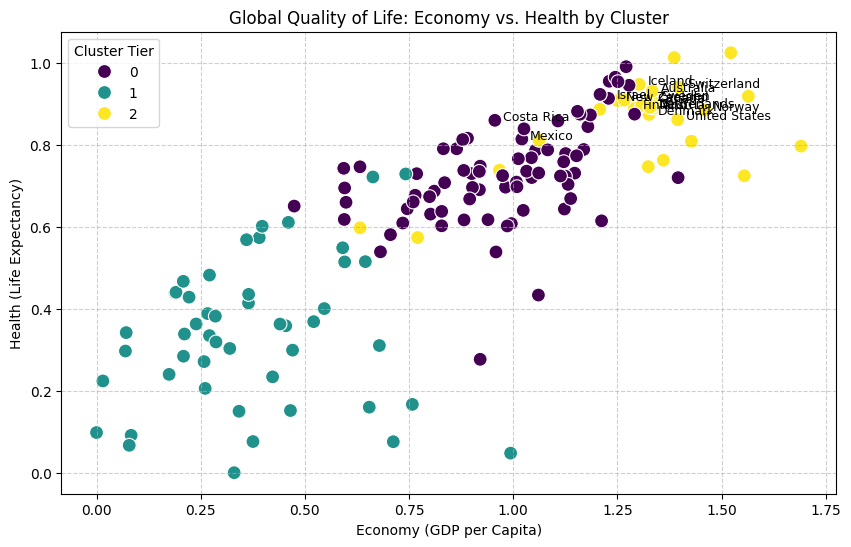

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['Economy (GDP per Capita)'],
    y=df['Health (Life Expectancy)'],
    hue=df['Cluster'],
    palette='viridis',
    s=100,
    data=df
)

plt.title('Global Quality of Life: Economy vs. Health by Cluster')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Health (Life Expectancy)')
plt.grid(True, linestyle='--', alpha=0.6)

# Optionally annotate a few key countries as meta labels
for i, row in df.head(15).iterrows():
    plt.text(row['Economy (GDP per Capita)'] + 0.02, row['Health (Life Expectancy)'], row['Country'], fontsize=9)

plt.legend(title='Cluster Tier')
plt.show()